# Dataset Preview (HaluEval)

## Goals
1. Verify that the processed splits load correctly (`train/val/test`).
2. Show a simple “before/after” view: separate `prompt/response` vs. a combined `text` field.
3. Inspect basic distributions: `label`, `task`, and text lengths.
4. Display a few random examples of hallucinations vs. non-hallucinations.

> This notebook is intentionally lightweight and visual. It does not train models.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 140)

# --- Repo bootstrap (running from notebooks/) ---
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.load_splits import load_splits

train_df, val_df, test_df = load_splits(root=ROOT)

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

# Use a stable sample for faster visuals
sample = train_df.sample(2000, random_state=42).copy()
sample.head(3)


Train shape: (51647, 7)
Val shape:   (6425, 7)
Test shape:  (6435, 7)


,id,group_id,task,prompt,response,label,context
13005,dialogue_8136_hall,dialogue_8136,dialogue,[Human]: Do you like Will Smith? [Assistant]: Absolutely! I love The Pursuit of Happyness. Have you seen it? [Human]: Maybe did he kill ...,"Yes, he killed himself in the end to save others in The Pursuit of Happyness.",1,Will Smith starred in The Pursuit of Happyness. The Pursuit of Happyness is starring Jaden SmithThe Pursuit of Happyness is starring Wil...
36568,summarization_2788_gt,summarization_2788,summarization,Three people have been killed after clubbers stampeded into a nightclub to see a British punk band called Doom. The crowd tried to storm...,"Three people were killed and seven were seriously injured in the crush. The music vans were trying to get into club Tsunami in Santiago,...",0,NaN
20664,qa_2904_gt,qa_2904,qa,What is the nationality of the man who Andry Thysse challenged for the World Boxing Council International super middleweight title,Danish,0,"Andre Thysse ( (1968--) 07 1968 (age (2017)-(1968)-((11)<(02)or(11)==(02)and(30)<(07)) ) ) born in Germiston, is a South African profess..."


In [2]:
# BEFORE: prompt/response are stored separately (useful for feature engineering)
sample[["task", "label", "prompt", "response"]].head(2)

# AFTER: create a combined text field (useful for TF-IDF baselines)
sample = sample.copy()
sample["text"] = sample["prompt"].fillna("").astype(str) + "\n\n" + sample["response"].fillna("").astype(str)

sample[["task", "label", "text"]].head(2)


,task,label,text
13005,dialogue,1,[Human]: Do you like Will Smith? [Assistant]: Absolutely! I love The Pursuit of Happyness. Have you seen it? [Human]: Maybe did he kill ...
36568,summarization,0,Three people have been killed after clubbers stampeded into a nightclub to see a British punk band called Doom. The crowd tried to storm...


## Label distribution (Train)

Train label counts: {0: 27605, 1: 24042}


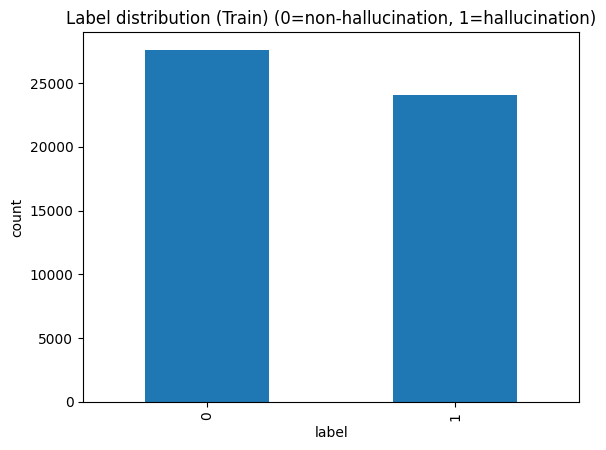

In [3]:
label_counts = train_df["label"].value_counts().sort_index()
print("Train label counts:", label_counts.to_dict())

label_counts.plot(kind="bar")
plt.title("Label distribution (Train) (0=non-hallucination, 1=hallucination)")
plt.xlabel("label")
plt.ylabel("count")
plt.show()


## Task distribution (Train)

Train task counts (top 20): {'summarization': 16054, 'dialogue': 16020, 'qa': 16010, 'general': 3563}


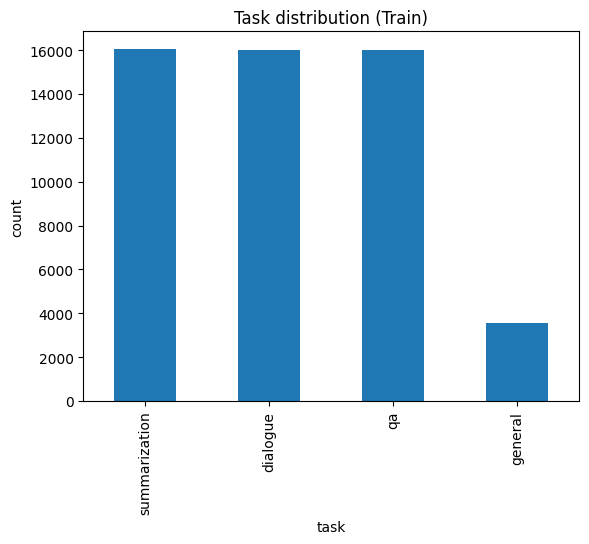

In [4]:
task_counts = train_df["task"].value_counts()
print("Train task counts (top 20):", task_counts.head(20).to_dict())

task_counts.plot(kind="bar")
plt.title("Task distribution (Train)")
plt.xlabel("task")
plt.ylabel("count")
plt.show()


## Length distributions (sample)

        prompt_len  response_len
count  2000.000000   2000.000000
mean   1239.912500    179.129500
std    1935.334832    186.788631
min      23.000000      2.000000
25%     100.000000     43.000000
50%     257.000000    102.000000
75%    1836.750000    274.000000
max    9919.000000    949.000000


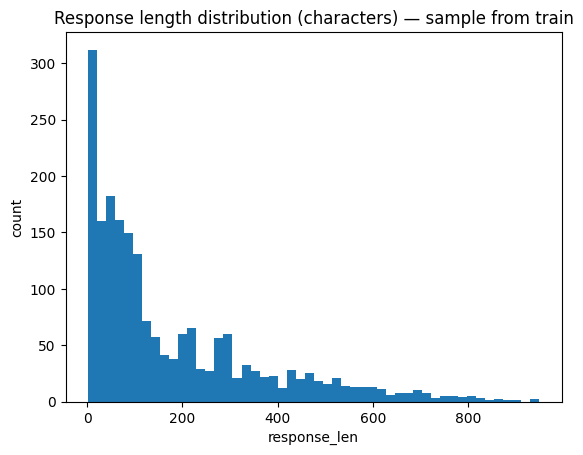

In [5]:
df2 = sample.copy()
df2["prompt_len"] = df2["prompt"].fillna("").astype(str).str.len()
df2["response_len"] = df2["response"].fillna("").astype(str).str.len()

print(df2[["prompt_len", "response_len"]].describe())

df2["response_len"].plot(kind="hist", bins=50)
plt.title("Response length distribution (characters) — sample from train")
plt.xlabel("response_len")
plt.ylabel("count")
plt.show()


## Length vs. label (boxplot, sample)

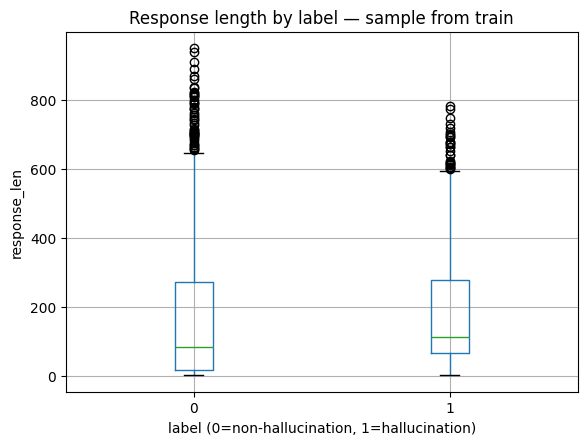

In [6]:
# Visual comparison: do hallucinations tend to be longer/shorter?
df2.boxplot(column="response_len", by="label")
plt.title("Response length by label — sample from train")
plt.suptitle("")  # remove pandas auto-title
plt.xlabel("label (0=non-hallucination, 1=hallucination)")
plt.ylabel("response_len")
plt.show()



## Random examples (train)

In [7]:
def show_examples(df: pd.DataFrame, label: int, n: int = 2, seed: int = 1, max_chars: int = 800) -> None:
    ex = df[df["label"] == label].sample(n, random_state=seed)
    for i, row in enumerate(ex.itertuples(index=False), 1):
        prompt = "" if pd.isna(row.prompt) else str(row.prompt)
        response = "" if pd.isna(row.response) else str(row.response)

        print("=" * 100)
        print(f"Example #{i} | task={row.task} | label={row.label}")
        print("- prompt:")
        print(prompt[:max_chars] + (" ..." if len(prompt) > max_chars else ""))
        print("\n- response:")
        print(response[:max_chars] + (" ..." if len(response) > max_chars else ""))

print("### Examples: Hallucination (label=1)")
show_examples(train_df, label=1, n=2, seed=42)

print("\n\n### Examples: Non-hallucination (label=0)")
show_examples(train_df, label=0, n=2, seed=42)


### Examples: Hallucination (label=1)
Example #1 | task=summarization | label=1
- prompt:
David Cameron will launch a multi-billion pound sale of Lloyds Bank shares if he wins the Election – in what would be the largest privatisation bonanza since the Thatcher era. The Prime Minister will today pledge that if he is returned to Downing Street he will offer the public £4 billion of Lloyds shares still held by the Government after Gordon Brown’s £20 billion panic bailout with taxpayers’ money during the 2008 economic crisis. Individuals will be allowed to buy up to £10,000 worth of Lloyds Banking Group shares, which were worth 78.7p when the stock market closed on Friday – comfortably above the 73.6p paid by Mr Brown’s government. Scroll down for video. David Cameron will launch a multi-billion pound sale of Lloyds Bank shares if he wins the Election. The shares will be offered at ...

- response:
The public has been urged to invest in Lloyds Bank shares worth £4bn, the largest privatisat

## Notes / Limitations
- Visualizations use a fixed-size sample for speed.
- Label and task distributions are computed on the full training split.
- This notebook is meant for sanity-checking the processed schema and basic dataset characteristics.
